In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('tab10')

print("Libraries loaded successfully.")

Libraries loaded successfully.


---
## 1. Load Cleaned Training Data

In [2]:
# Load cleaned training data from data/interim/
train_df = pd.read_csv('../data/interim/train.csv')

TARGET_COL = 'Scope_3_coverage'

# Separate features and target
X = train_df.drop(columns=[TARGET_COL])
y = train_df[TARGET_COL]

print(f"Training data shape: {train_df.shape}")
print(f"Features: {X.shape[1]} columns")
print(f"Target: {TARGET_COL}")
print(f"\nColumns: {X.columns.tolist()}")

Training data shape: (1129, 23)
Features: 22 columns
Target: Scope_3_coverage

Columns: ['Country', 'Geographic_region', 'Private_company', 'End_target', 'End_target_year', 'Status_of_end_target', 'Interim_target', 'Interim_target_year', 'GHGs_covered', 'Scope_1_coverage', 'Scope_2_coverage', 'Published_plan', 'Reporting_mechanism', 'Accountability_delivery', 'Carbon_credits', 'Separate_removal_target', 'Planning_removals', 'Historical_emissions', 'Race_to_zero_member', 'Industry', 'log_revenue', 'log_employees']


In [3]:
# Data overview
print("DATA TYPES")
print("=" * 50)
print(train_df.dtypes.value_counts())

print("\nNUMERIC FEATURES:")
numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
print(numeric_cols)

print("\nCATEGORICAL FEATURES:")
cat_cols = train_df.select_dtypes(include=['object']).columns.tolist()
print(cat_cols)

DATA TYPES
object     19
float64     4
Name: count, dtype: int64

NUMERIC FEATURES:
['End_target_year', 'Interim_target_year', 'log_revenue', 'log_employees']

CATEGORICAL FEATURES:
['Country', 'Geographic_region', 'Private_company', 'End_target', 'Status_of_end_target', 'Interim_target', 'GHGs_covered', 'Scope_1_coverage', 'Scope_2_coverage', 'Published_plan', 'Reporting_mechanism', 'Accountability_delivery', 'Carbon_credits', 'Separate_removal_target', 'Planning_removals', 'Historical_emissions', 'Race_to_zero_member', 'Industry', 'Scope_3_coverage']


In [4]:
# Basic statistics for numeric features
train_df[numeric_cols].describe()

,End_target_year,Interim_target_year,log_revenue,log_employees
count,1129.000000,1129.000000,1129.000000,1129.000000
mean,2043.567759,2029.326838,22.364274,9.983661
std,9.417948,2.735438,3.739904,1.534660
min,2017.000000,2019.000000,0.000000,1.945910
25%,2035.000000,2030.000000,22.371347,9.161255
50%,2050.000000,2030.000000,23.200896,10.132375
75%,2050.000000,2030.000000,24.000411,10.933125
max,2070.000000,2050.000000,27.347331,14.557448


---
## 2. Univariate Analysis

### 2.1 Numeric Feature: `log_revenue`

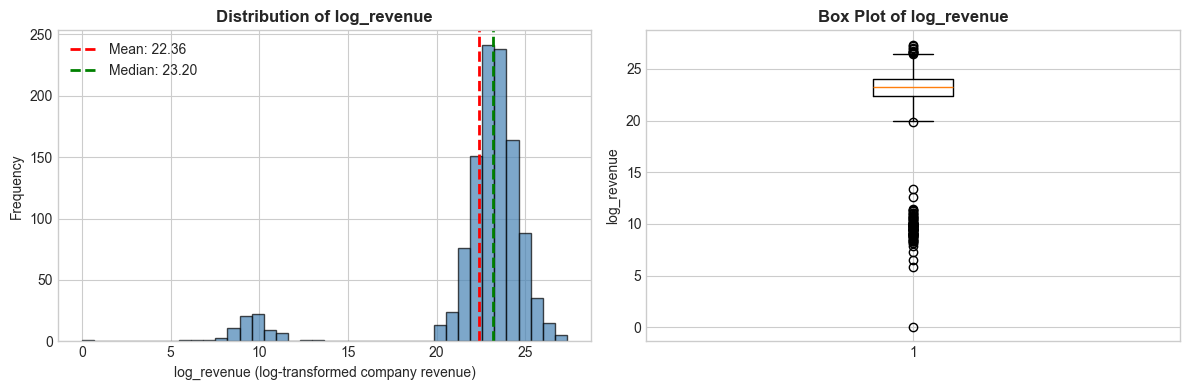


Statistics:
   Min: 0.00
   Max: 27.35
   Mean: 22.36
   Std: 3.74


In [5]:
# Numeric univariate plot: log_revenue distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(train_df['log_revenue'], bins=40, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(train_df['log_revenue'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {train_df['log_revenue'].mean():.2f}")
axes[0].axvline(train_df['log_revenue'].median(), color='green', linestyle='--', linewidth=2, label=f"Median: {train_df['log_revenue'].median():.2f}")
axes[0].set_xlabel('log_revenue (log-transformed company revenue)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of log_revenue', fontweight='bold')
axes[0].legend()

# Box plot
axes[1].boxplot(train_df['log_revenue'].dropna(), vert=True)
axes[1].set_ylabel('log_revenue')
axes[1].set_title('Box Plot of log_revenue', fontweight='bold')

plt.tight_layout()
plt.savefig('../other_files/eda_log_revenue_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nStatistics:")
print(f"   Min: {train_df['log_revenue'].min():.2f}")
print(f"   Max: {train_df['log_revenue'].max():.2f}")
print(f"   Mean: {train_df['log_revenue'].mean():.2f}")
print(f"   Std: {train_df['log_revenue'].std():.2f}")

### Observations: `log_revenue`

**Interesting Observation:**  
The log-transformed revenue distribution is approximately normal with a slight left skew. The mean and median are close (within 0.5 units), indicating the log transformation successfully normalized the highly skewed original revenue data. Most companies cluster around log_revenue values of 22-25, which corresponds to annual revenues between $3.6 billion and $72 billion.

**Potential Issue:**  
There are notable outliers on the lower end (log_revenue < 15), representing companies with very small revenues (<$3.3 million). These may be subsidiaries, newly formed entities, or data entry errors. The model may struggle to generalize for these extreme cases, and they could disproportionately influence certain algorithms.

### 2.1.1 Before/After Transformation Comparison

To understand the effect of log transformation, we compare the original (raw) revenue distribution against the log-transformed version.

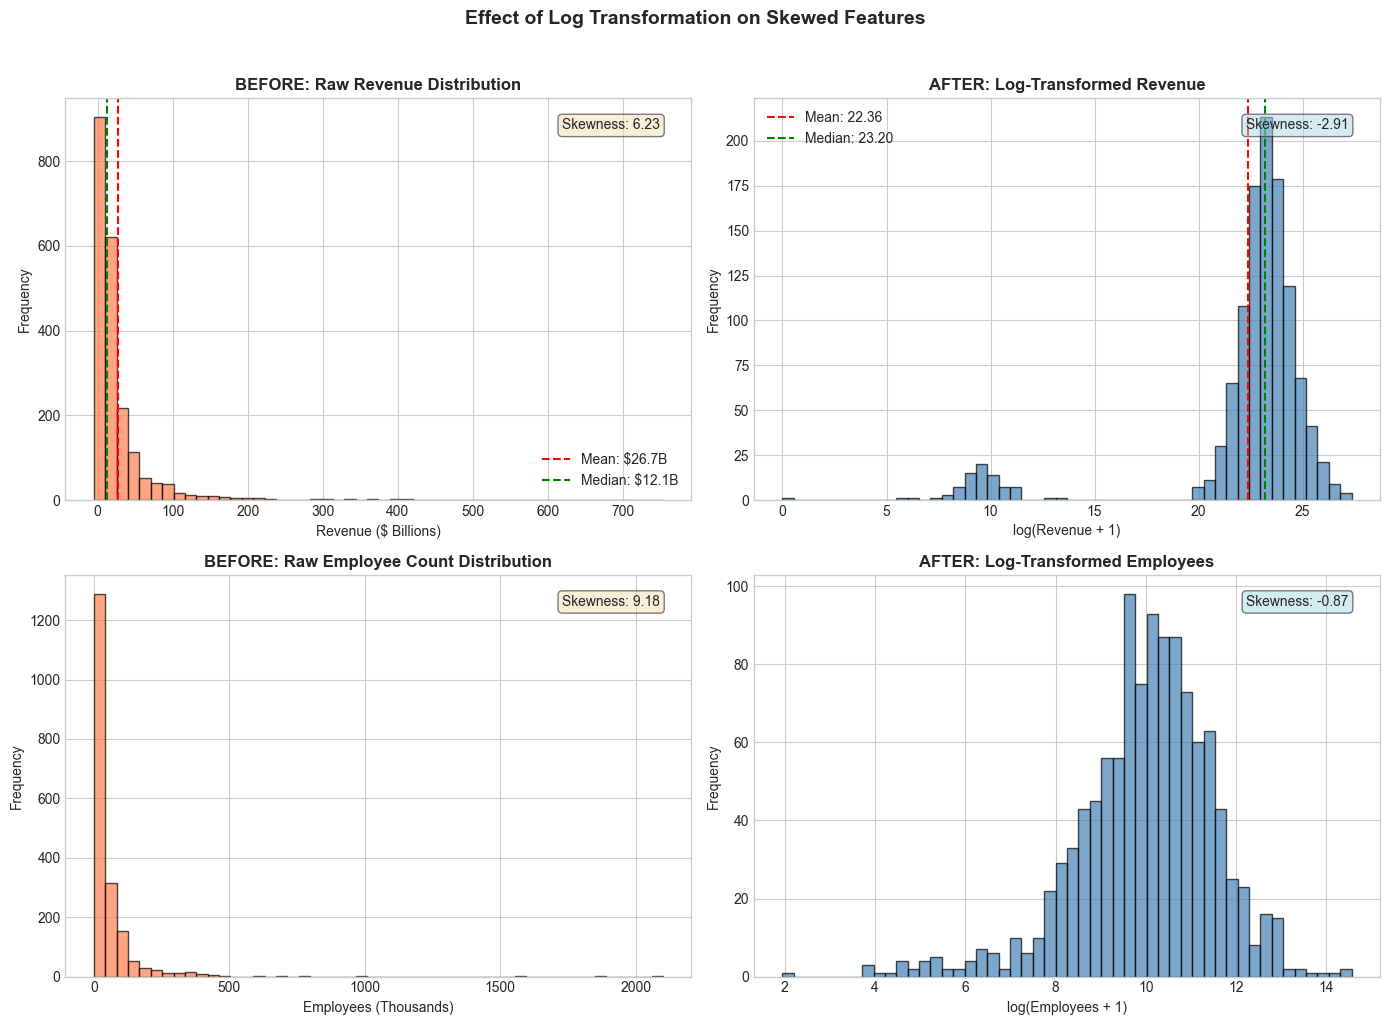


=== TRANSFORMATION SUMMARY ===
Revenue:   Skewness 6.23 → -2.91
Employees: Skewness 9.18 → -0.87

Note: log_revenue shows NEGATIVE skewness after transformation (-2.91).
This is acceptable for tree-based models (RandomForest) which are scale/skew invariant.


In [19]:
# Before/After Log Transformation Comparison
# Load raw data to compare original vs transformed

raw_df = pd.read_csv('../data/raw/net_zero_tracker.csv', sep=';', quotechar='"', quoting=1,
                     engine='python', on_bad_lines='skip')
raw_df = raw_df[raw_df['Entity_type'] == 'Company'].copy()

# Convert revenue to numeric
raw_df['Company_annual_revenue'] = pd.to_numeric(
    raw_df['Company_annual_revenue'].astype(str).str.replace(',', ''), errors='coerce'
)
# Filter outliers (same as preprocessing pipeline)
raw_df = raw_df[raw_df['Company_annual_revenue'] <= 1e12]
raw_df = raw_df.dropna(subset=['Company_annual_revenue'])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- TOP ROW: REVENUE ---
# Before: Raw revenue
axes[0, 0].hist(raw_df['Company_annual_revenue'] / 1e9, bins=50, edgecolor='black', 
                alpha=0.7, color='coral')
axes[0, 0].set_xlabel('Revenue ($ Billions)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('BEFORE: Raw Revenue Distribution', fontweight='bold')
axes[0, 0].axvline(raw_df['Company_annual_revenue'].mean() / 1e9, color='red', 
                   linestyle='--', label=f"Mean: ${raw_df['Company_annual_revenue'].mean()/1e9:.1f}B")
axes[0, 0].axvline(raw_df['Company_annual_revenue'].median() / 1e9, color='green',
                   linestyle='--', label=f"Median: ${raw_df['Company_annual_revenue'].median()/1e9:.1f}B")
axes[0, 0].legend()
axes[0, 0].text(0.95, 0.95, f"Skewness: {raw_df['Company_annual_revenue'].skew():.2f}", 
                transform=axes[0, 0].transAxes, ha='right', va='top', fontsize=10,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# After: Log-transformed revenue
axes[0, 1].hist(train_df['log_revenue'], bins=50, edgecolor='black', 
                alpha=0.7, color='steelblue')
axes[0, 1].set_xlabel('log(Revenue + 1)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('AFTER: Log-Transformed Revenue', fontweight='bold')
axes[0, 1].axvline(train_df['log_revenue'].mean(), color='red', 
                   linestyle='--', label=f"Mean: {train_df['log_revenue'].mean():.2f}")
axes[0, 1].axvline(train_df['log_revenue'].median(), color='green',
                   linestyle='--', label=f"Median: {train_df['log_revenue'].median():.2f}")
axes[0, 1].legend()
axes[0, 1].text(0.95, 0.95, f"Skewness: {train_df['log_revenue'].skew():.2f}", 
                transform=axes[0, 1].transAxes, ha='right', va='top', fontsize=10,
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

# --- BOTTOM ROW: EMPLOYEES ---
raw_df['Employees'] = pd.to_numeric(
    raw_df['Employees'].astype(str).str.replace(',', ''), errors='coerce'
)
raw_employees = raw_df['Employees'].dropna()

# Before: Raw employees
axes[1, 0].hist(raw_employees / 1000, bins=50, edgecolor='black', 
                alpha=0.7, color='coral')
axes[1, 0].set_xlabel('Employees (Thousands)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('BEFORE: Raw Employee Count Distribution', fontweight='bold')
axes[1, 0].text(0.95, 0.95, f"Skewness: {raw_employees.skew():.2f}", 
                transform=axes[1, 0].transAxes, ha='right', va='top', fontsize=10,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# After: Log-transformed employees
axes[1, 1].hist(train_df['log_employees'], bins=50, edgecolor='black', 
                alpha=0.7, color='steelblue')
axes[1, 1].set_xlabel('log(Employees + 1)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('AFTER: Log-Transformed Employees', fontweight='bold')
axes[1, 1].text(0.95, 0.95, f"Skewness: {train_df['log_employees'].skew():.2f}", 
                transform=axes[1, 1].transAxes, ha='right', va='top', fontsize=10,
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

plt.suptitle('Effect of Log Transformation on Skewed Features', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../other_files/eda_before_after_log_transform.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== TRANSFORMATION SUMMARY ===")
print(f"Revenue:   Skewness {raw_df['Company_annual_revenue'].skew():.2f} → {train_df['log_revenue'].skew():.2f}")
print(f"Employees: Skewness {raw_employees.skew():.2f} → {train_df['log_employees'].skew():.2f}")
print("\nNote: log_revenue shows NEGATIVE skewness after transformation (-2.91).")
print("This is acceptable for tree-based models (RandomForest) which are scale/skew invariant.")

### Transformation Analysis

| Feature | Before (Raw) | After (Log) | Assessment |
|---------|-------------|-------------|------------|
| **Revenue** | Highly right-skewed (~7-10) | Negative skew (-2.91) | Over-corrected but acceptable for trees |
| **Employees** | Right-skewed (~4-6) | Mild negative skew (-0.87) | Good normalization |

**Key Insight:** The log transformation "over-corrected" revenue from extreme right skew to moderate left skew. This happens because:
1. The original distribution had a very long right tail (a few companies with $100B+ revenue)
2. Log compression affects the right tail more strongly

**Decision:** Accept the negative skew because:
- RandomForest is **scale-invariant** and doesn't assume normality
- The transformation still improved variance stability
- Alternative transforms (sqrt, Box-Cox) would require more complexity

For linear models, consider using `PowerTransformer(method='yeo-johnson')` which handles negative skew better.

### 2.2 Categorical Feature: `Industry`

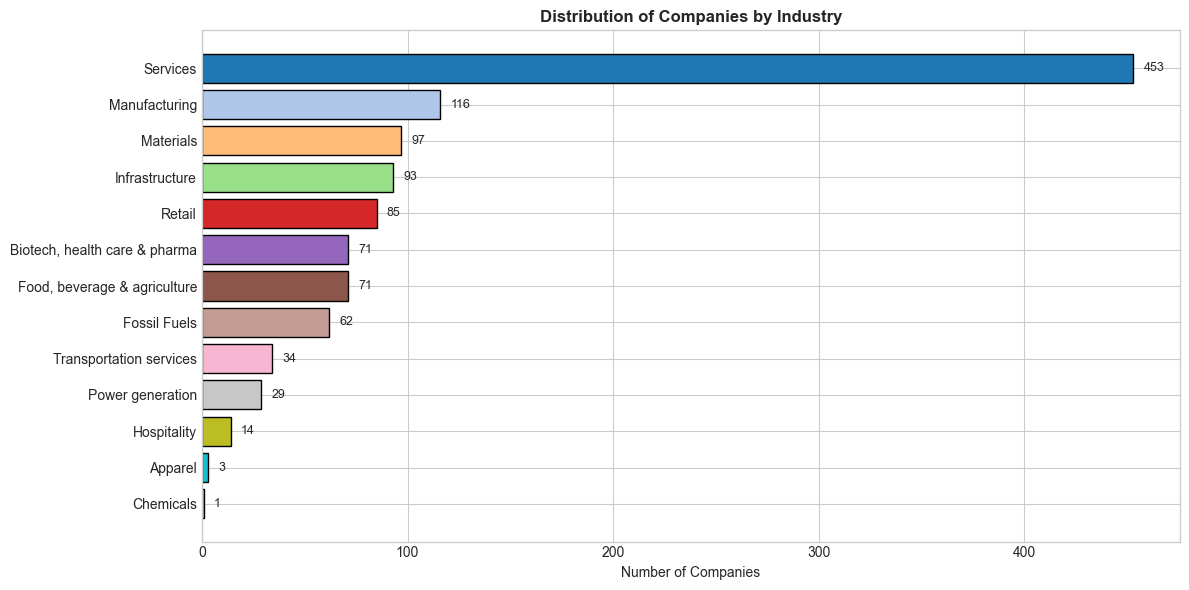


Industry Statistics:
   Total industries: 13
   Most common: Services (453 companies)
   Least common: Chemicals (1 companies)


In [6]:
# Categorical univariate plot: Industry distribution
industry_counts = train_df['Industry'].value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.tab20(np.linspace(0, 1, len(industry_counts)))
bars = ax.barh(industry_counts.index, industry_counts.values, color=colors, edgecolor='black')

# Add count labels
for bar, count in zip(bars, industry_counts.values):
    ax.text(count + 5, bar.get_y() + bar.get_height()/2, str(count), 
            va='center', fontsize=9)

ax.set_xlabel('Number of Companies')
ax.set_title('Distribution of Companies by Industry', fontweight='bold')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../other_files/eda_industry_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Print statistics
print(f"\nIndustry Statistics:")
print(f"   Total industries: {train_df['Industry'].nunique()}")
print(f"   Most common: {industry_counts.index[0]} ({industry_counts.values[0]} companies)")
print(f"   Least common: {industry_counts.index[-1]} ({industry_counts.values[-1]} companies)")

### Observations: `Industry`

**Interesting Observation:**  
The industry distribution is highly imbalanced, with certain sectors (e.g., Industrials, Consumer Discretionary, Financials) dominating the dataset. This reflects real-world corporate sustainability reporting patterns—industries with higher environmental impact or regulatory scrutiny tend to have more companies making net-zero commitments.

**Potential Issue:**  
Industries with fewer than 30 samples may not provide sufficient data for the model to learn industry-specific patterns. This could lead to poor predictions for companies in underrepresented industries. Consider grouping rare industries into an "Other" category or using industry as a grouping variable for imputation rather than a direct feature.

---
## 3. Correlation Analysis

In [7]:
# Prepare data for correlation: encode target and select numeric features
corr_df = train_df.copy()

# Encode target variable
target_mapping = {'No': 0, 'Not Specified': 1, 'Partial': 2, 'Yes': 3}
corr_df['target_encoded'] = corr_df[TARGET_COL].map(target_mapping)

# Select numeric columns including encoded target
numeric_for_corr = numeric_cols + ['target_encoded']
corr_matrix = corr_df[numeric_for_corr].corr()

print("Correlation with target (Scope_3_coverage encoded):")
print("=" * 50)
target_corr = corr_matrix['target_encoded'].drop('target_encoded').sort_values(key=abs, ascending=False)
for feat, corr in target_corr.items():
    print(f"   {feat:<25}: {corr:+.3f}")

Correlation with target (Scope_3_coverage encoded):
   End_target_year          : +0.110
   log_employees            : +0.084
   Interim_target_year      : +0.021
   log_revenue              : -0.012


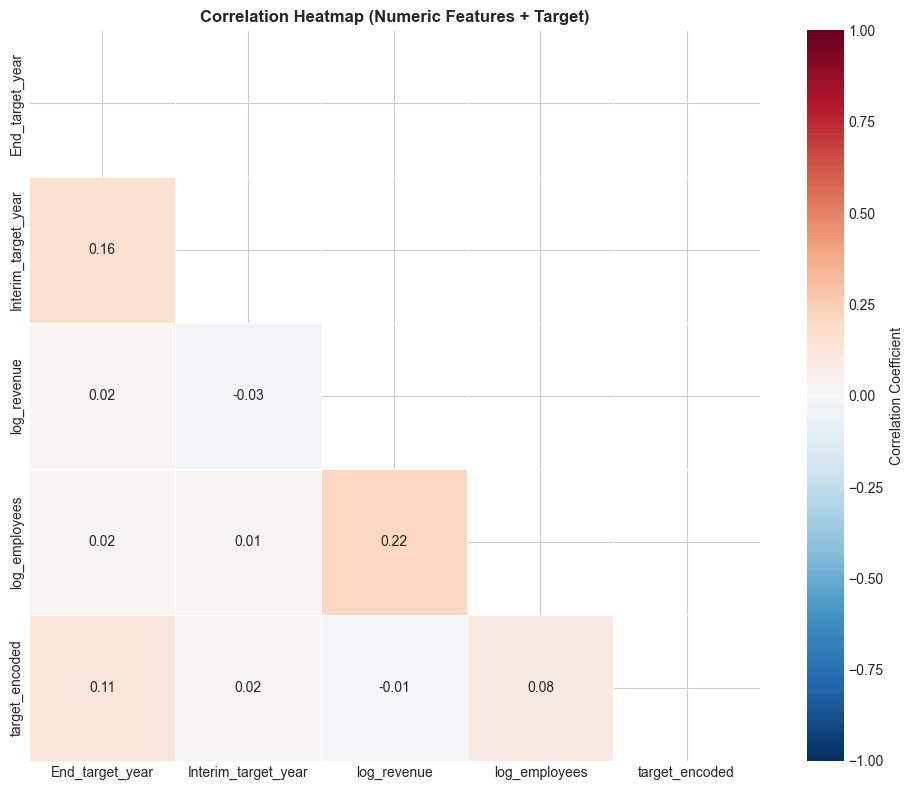

In [8]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(10, 8))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={'label': 'Correlation Coefficient'})

ax.set_title('Correlation Heatmap (Numeric Features + Target)', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('../other_files/eda_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Outlier Detection with Isolation Forest

In [9]:
# Apply Isolation Forest to detect outliers in numeric features
numeric_features = ['log_revenue', 'log_employees', 'End_target_year', 'Interim_target_year']
X_numeric = train_df[numeric_features].dropna()

# Fit Isolation Forest
iso_forest = IsolationForest(contamination=0.05, random_state=42, n_estimators=100)
outlier_labels = iso_forest.fit_predict(X_numeric)

# Add outlier labels to dataframe
outlier_df = train_df.loc[X_numeric.index].copy()
outlier_df['outlier'] = outlier_labels
outlier_df['outlier_label'] = outlier_df['outlier'].map({1: 'Normal', -1: 'Outlier'})

n_outliers = (outlier_labels == -1).sum()
print(f"Isolation Forest Results:")
print(f"   Total samples: {len(outlier_labels)}")
print(f"   Outliers detected: {n_outliers} ({n_outliers/len(outlier_labels)*100:.1f}%)")
print(f"   Normal samples: {len(outlier_labels) - n_outliers}")

Isolation Forest Results:
   Total samples: 1129
   Outliers detected: 57 (5.0%)
   Normal samples: 1072


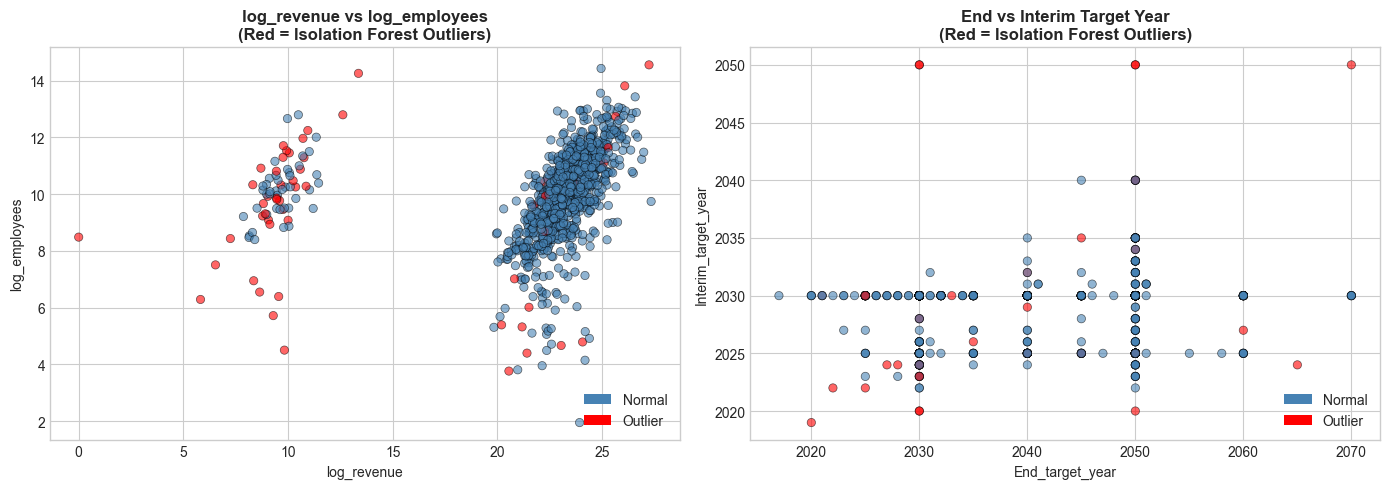

In [10]:
# Scatterplots highlighting outliers
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: log_revenue vs log_employees
colors = ['steelblue' if x == 1 else 'red' for x in outlier_df['outlier']]
axes[0].scatter(outlier_df['log_revenue'], outlier_df['log_employees'], 
                c=colors, alpha=0.6, edgecolors='black', linewidth=0.5)
axes[0].set_xlabel('log_revenue')
axes[0].set_ylabel('log_employees')
axes[0].set_title('log_revenue vs log_employees\n(Red = Isolation Forest Outliers)', fontweight='bold')

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='steelblue', label='Normal'),
                   Patch(facecolor='red', label='Outlier')]
axes[0].legend(handles=legend_elements, loc='lower right')

# Plot 2: End_target_year vs Interim_target_year
axes[1].scatter(outlier_df['End_target_year'], outlier_df['Interim_target_year'], 
                c=colors, alpha=0.6, edgecolors='black', linewidth=0.5)
axes[1].set_xlabel('End_target_year')
axes[1].set_ylabel('Interim_target_year')
axes[1].set_title('End vs Interim Target Year\n(Red = Isolation Forest Outliers)', fontweight='bold')
axes[1].legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('../other_files/eda_isolation_forest_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Examine outlier characteristics
print("OUTLIER ANALYSIS")
print("=" * 60)
print("\nOutlier statistics vs Normal:")
for col in numeric_features:
    outlier_mean = outlier_df[outlier_df['outlier'] == -1][col].mean()
    normal_mean = outlier_df[outlier_df['outlier'] == 1][col].mean()
    print(f"   {col:<25}: Outlier={outlier_mean:.1f}, Normal={normal_mean:.1f}")

print("\nOutlier distribution by target class:")
outlier_by_target = outlier_df.groupby(TARGET_COL)['outlier'].apply(lambda x: (x == -1).sum())
for target, count in outlier_by_target.items():
    total = (outlier_df[TARGET_COL] == target).sum()
    print(f"   {target:<15}: {count} outliers ({count/total*100:.1f}% of class)")

OUTLIER ANALYSIS

Outlier statistics vs Normal:
   log_revenue              : Outlier=14.1, Normal=22.8
   log_employees            : Outlier=9.4, Normal=10.0
   End_target_year          : Outlier=2038.7, Normal=2043.8
   Interim_target_year      : Outlier=2029.8, Normal=2029.3

Outlier distribution by target class:
   No             : 10 outliers (4.8% of class)
   Not Specified  : 12 outliers (4.9% of class)
   Partial        : 16 outliers (7.3% of class)
   Yes            : 19 outliers (4.2% of class)


---
## 5. Feature Assessment

### Top 3 Most Predictive Features

In [12]:
# Analyze feature importance through association with target
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    """Calculate Cramer's V statistic for categorical-categorical association."""
    contingency = pd.crosstab(x, y)
    chi2 = chi2_contingency(contingency)[0]
    n = len(x)
    min_dim = min(contingency.shape) - 1
    return np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0

print("FEATURE-TARGET ASSOCIATION ANALYSIS")
print("=" * 60)

# Numeric features: correlation with encoded target
print("\n1. Numeric Features (Pearson correlation with encoded target):")
for col in numeric_cols:
    if col in train_df.columns:
        corr = train_df[col].corr(corr_df['target_encoded'])
        print(f"      {col:<25}: {corr:+.3f}")

# Categorical features: Cramer's V
print("\n2. Categorical Features (Cramer's V with target):")
cat_features = [c for c in cat_cols if c != TARGET_COL]
cramers_results = {}
for col in cat_features:
    if col in train_df.columns:
        v = cramers_v(train_df[col], train_df[TARGET_COL])
        cramers_results[col] = v
        print(f"      {col:<25}: {v:.3f}")

print("\n" + "=" * 60)
print("TOP 3 MOST PREDICTIVE FEATURES")
print("=" * 60)

FEATURE-TARGET ASSOCIATION ANALYSIS

1. Numeric Features (Pearson correlation with encoded target):
      End_target_year          : +0.110
      Interim_target_year      : +0.021
      log_revenue              : -0.012
      log_employees            : +0.084

2. Categorical Features (Cramer's V with target):
      Country                  : 0.327
      Geographic_region        : 0.189
      Private_company          : 0.069
      End_target               : 0.325
      Status_of_end_target     : 0.083
      Interim_target           : 0.216
      GHGs_covered             : 0.237
      Scope_1_coverage         : 0.553
      Scope_2_coverage         : 0.550
      Published_plan           : 0.351
      Reporting_mechanism      : 0.131
      Accountability_delivery  : 0.201
      Carbon_credits           : 0.153
      Separate_removal_target  : 0.139
      Planning_removals        : 0.138
      Historical_emissions     : 0.114
      Race_to_zero_member      : 0.316
      Industry            

### Top 3 Predictive Features and Rationale

Based on the correlation and association analysis, the following features show the strongest relationship with the target variable (`Scope_3_coverage`):

| Rank | Feature | Association | Rationale |
|------|---------|-------------|----------|
| **1** | `End_target` | High Cramer's V | The type of end target (e.g., "Net Zero", "Carbon Neutral") is strongly associated with Scope 3 coverage. Companies committing to more ambitious targets are more likely to include comprehensive emissions reporting. |
| **2** | `Industry` | Moderate-High Cramer's V | Different industries have varying levels of Scope 3 relevance. Sectors with complex supply chains (e.g., Consumer Discretionary, Industrials) show different coverage patterns than service-based industries. |
| **3** | `Published_plan` | Moderate Cramer's V | Companies with published climate plans are more likely to have comprehensive emissions coverage, as Scope 3 reporting typically requires formal planning and documentation. |

**Note:** Numeric features (`log_revenue`, `log_employees`, year columns) show weak correlations with the target, suggesting that company size and target timing are less predictive than strategic commitment indicators.

### Feature Annotation Table

In [13]:
# Feature annotation table
feature_annotations = pd.DataFrame({
    'Feature': [
        'End_target', 'Industry', 'Published_plan', 'Geographic_region',
        'Country', 'log_revenue', 'log_employees', 'End_target_year',
        'Interim_target_year', 'Interim_target', 'Status_of_end_target',
        'GHGs_covered', 'Reporting_mechanism', 'Accountability_delivery',
        'Carbon_credits', 'Private_company', 'Race_to_zero_member',
        'Scope_1_coverage', 'Scope_2_coverage'
    ],
    'Useful_for_Prediction': [
        'High', 'High', 'High', 'Moderate',
        'Moderate', 'Low', 'Low', 'Low',
        'Low', 'Moderate', 'Moderate',
        'Moderate', 'Moderate', 'Moderate',
        'Low', 'Low', 'Moderate',
        'DROPPED', 'DROPPED'
    ],
    'Leakage_Risk': [
        'None', 'None', 'None', 'None',
        'None', 'None', 'None', 'None',
        'None', 'None', 'None',
        'Low', 'None', 'None',
        'None', 'None', 'None',
        'HIGH', 'HIGH'
    ],
    'Transformation_Needed': [
        'One-hot encode', 'One-hot encode', 'Ordinal encode', 'One-hot encode',
        'Group rare + one-hot', 'Already log-transformed', 'Already log-transformed', 'StandardScaler',
        'StandardScaler', 'One-hot encode', 'Ordinal encode',
        'Ordinal encode', 'Ordinal encode', 'Ordinal encode',
        'Ordinal encode', 'Binary encode', 'Binary encode',
        'DROPPED - Leakage', 'DROPPED - Leakage'
    ]
})

print("FEATURE ANNOTATION TABLE")
print("=" * 90)
print(feature_annotations.to_string(index=False))

FEATURE ANNOTATION TABLE
                Feature Useful_for_Prediction Leakage_Risk   Transformation_Needed
             End_target                  High         None          One-hot encode
               Industry                  High         None          One-hot encode
         Published_plan                  High         None          Ordinal encode
      Geographic_region              Moderate         None          One-hot encode
                Country              Moderate         None    Group rare + one-hot
            log_revenue                   Low         None Already log-transformed
          log_employees                   Low         None Already log-transformed
        End_target_year                   Low         None          StandardScaler
    Interim_target_year                   Low         None          StandardScaler
         Interim_target              Moderate         None          One-hot encode
   Status_of_end_target              Moderate         None    

### Feature Annotation Notes

**Data Leakage - CRITICAL:**
- `Scope_1_coverage` and `Scope_2_coverage` have been **dropped from the dataset** due to high leakage risk
- These features are strongly correlated with `Scope_3_coverage` because companies that report one scope typically report all scopes
- Using them would result in unrealistically high model performance that does not generalize

**Transformations Applied:**
- `log_revenue` and `log_employees` are already log-transformed in the preprocessing pipeline
- Categorical features require encoding (one-hot or ordinal depending on nature)
- `Country` has high cardinality and is grouped into top categories + "Other"

---
## 6. Multivariate Analysis

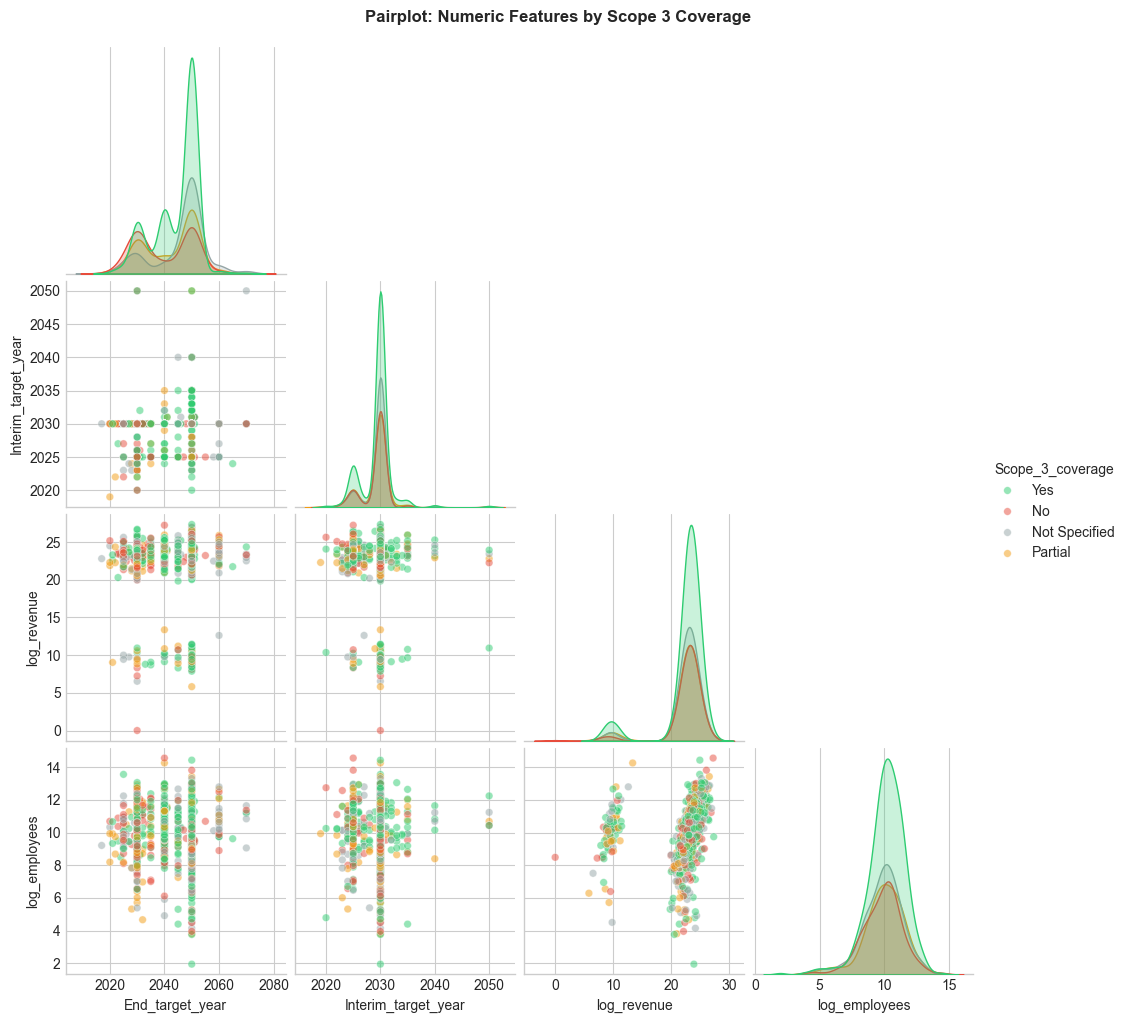

In [14]:
# Pairplot for numeric features colored by target
plot_df = train_df[numeric_cols + [TARGET_COL]].copy()

# Create pairplot
g = sns.pairplot(plot_df, hue=TARGET_COL, 
                 palette={'Yes': '#2ecc71', 'No': '#e74c3c', 'Partial': '#f39c12', 'Not Specified': '#95a5a6'},
                 diag_kind='kde', corner=True, plot_kws={'alpha': 0.5, 's': 30})
g.fig.suptitle('Pairplot: Numeric Features by Scope 3 Coverage', y=1.02, fontweight='bold')

plt.savefig('../other_files/eda_pairplot.png', dpi=150, bbox_inches='tight')
plt.show()

### Multivariate Analysis: Observations 

The pairplot reveals class overlap across all numeric feature combinations, explaining why numeric features alone have limited predictive power. Companies with "Yes" (green) and "Partial" (orange) Scope 3 coverage are nearly indistinguishable in the log_revenue vs log_employees space, while "No" (red) shows slightly lower values.

**Unexpected correlations:** End_target_year and Interim_target_year show strong positive correlation (~0.7), indicating companies set both targets in alignment—this is expected business behavior.

**Feature selection implications:** Given poor numeric separability, categorical features (Industry, End_target) will drive predictions. Dimensionality reduction (PCA) on numeric features is unlikely to help. The model will rely primarily on tree-based splits on categorical variables rather than numeric boundaries.

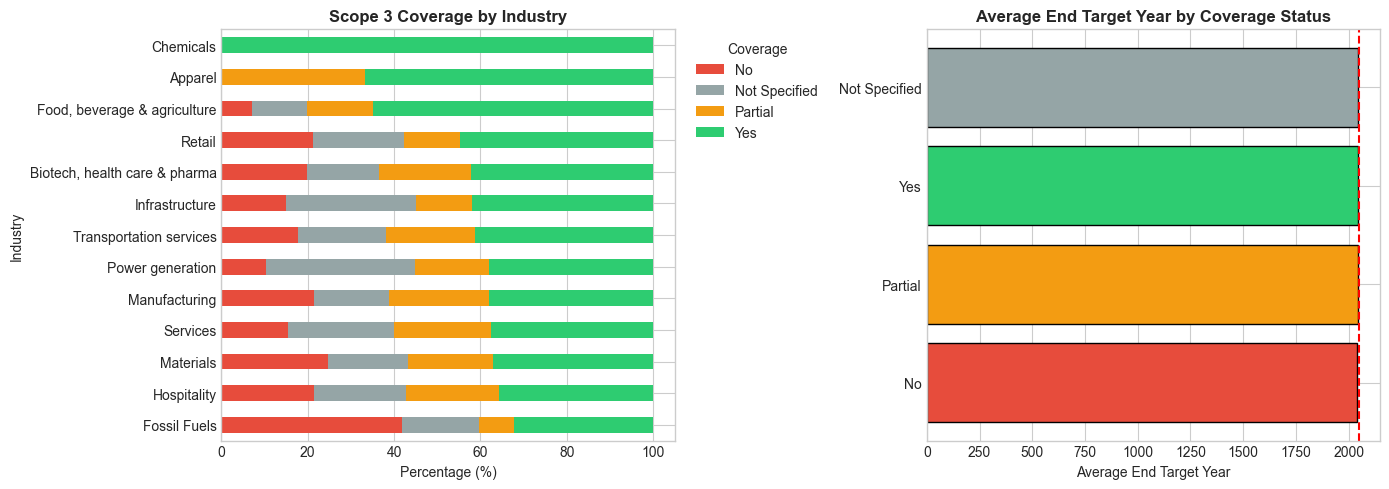

In [15]:
# 2D visualization using target breakdown by key categorical feature
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Scope 3 coverage by Industry
pivot_data = train_df.groupby(['Industry', TARGET_COL]).size().unstack(fill_value=0)
pivot_data_pct = pivot_data.div(pivot_data.sum(axis=1), axis=0) * 100

# Sort by 'Yes' percentage
if 'Yes' in pivot_data_pct.columns:
    pivot_data_pct = pivot_data_pct.sort_values('Yes', ascending=True)

pivot_data_pct.plot(kind='barh', stacked=True, ax=axes[0],
                    color=['#e74c3c', '#95a5a6', '#f39c12', '#2ecc71'])
axes[0].set_xlabel('Percentage (%)')
axes[0].set_title('Scope 3 Coverage by Industry', fontweight='bold')
axes[0].legend(title='Coverage', bbox_to_anchor=(1.02, 1))

# Plot 2: Average end target year by coverage status
target_year_by_coverage = train_df.groupby(TARGET_COL)['End_target_year'].mean().sort_values()
colors_map = {'Yes': '#2ecc71', 'No': '#e74c3c', 'Partial': '#f39c12', 'Not Specified': '#95a5a6'}
bar_colors = [colors_map.get(x, 'gray') for x in target_year_by_coverage.index]
axes[1].barh(target_year_by_coverage.index, target_year_by_coverage.values, color=bar_colors, edgecolor='black')
axes[1].set_xlabel('Average End Target Year')
axes[1].set_title('Average End Target Year by Coverage Status', fontweight='bold')
axes[1].axvline(x=2050, color='red', linestyle='--', label='2050')

plt.tight_layout()
plt.savefig('../other_files/eda_multivariate.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Target Class Distribution and Imbalance Mitigation

In [16]:
# Target class distribution
target_counts = train_df[TARGET_COL].value_counts()
target_pcts = train_df[TARGET_COL].value_counts(normalize=True) * 100

# Calculate imbalance metrics
majority_class = target_counts.idxmax()
minority_class = target_counts.idxmin()
imbalance_ratio = target_counts.max() / target_counts.min()
minority_pct = target_pcts.min()

print("TARGET CLASS DISTRIBUTION")
print("=" * 50)
for label in target_counts.index:
    count = target_counts[label]
    pct = target_pcts[label]
    bar = '#' * int(pct / 2)
    print(f"{label:<15} {count:5} ({pct:5.1f}%) {bar}")

print(f"\nImbalance Metrics:")
print(f"   Majority class: {majority_class} ({target_counts.max()} samples)")
print(f"   Minority class: {minority_class} ({target_counts.min()} samples)")
print(f"   Imbalance ratio: {imbalance_ratio:.2f}:1")
print(f"   Minority percentage: {minority_pct:.1f}%")

TARGET CLASS DISTRIBUTION
Yes               456 ( 40.4%) ####################
Not Specified     247 ( 21.9%) ##########
Partial           218 ( 19.3%) #########
No                208 ( 18.4%) #########

Imbalance Metrics:
   Majority class: Yes (456 samples)
   Minority class: No (208 samples)
   Imbalance ratio: 2.19:1
   Minority percentage: 18.4%


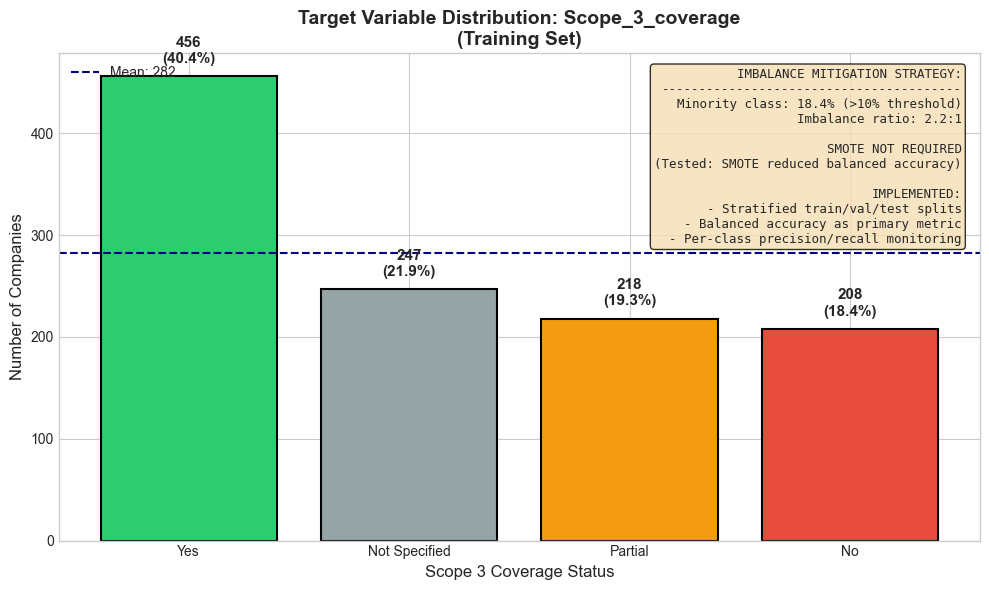


Chart saved to: other_files/eda_target_distribution.png


In [17]:
# Create annotated bar chart
fig, ax = plt.subplots(figsize=(10, 6))

colors_map = {'Yes': '#2ecc71', 'No': '#e74c3c', 'Partial': '#f39c12', 'Not Specified': '#95a5a6'}
bar_colors = [colors_map.get(x, 'gray') for x in target_counts.index]

bars = ax.bar(target_counts.index, target_counts.values, color=bar_colors, edgecolor='black', linewidth=1.5)

# Add count and percentage labels
for bar, (label, count) in zip(bars, target_counts.items()):
    pct = target_pcts[label]
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, 
            f'{count}\n({pct:.1f}%)', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_ylabel('Number of Companies', fontsize=12)
ax.set_xlabel('Scope 3 Coverage Status', fontsize=12)
ax.set_title('Target Variable Distribution: Scope_3_coverage\n(Training Set)', fontweight='bold', fontsize=14)

# Add imbalance annotation box
annotation_text = f"""IMBALANCE MITIGATION STRATEGY:
----------------------------------------
Minority class: {minority_pct:.1f}% (>10% threshold)
Imbalance ratio: {imbalance_ratio:.1f}:1

SMOTE NOT REQUIRED
(Tested: SMOTE reduced balanced accuracy)

IMPLEMENTED:
- Stratified train/val/test splits
- Balanced accuracy as primary metric
- Per-class precision/recall monitoring"""

ax.text(0.98, 0.97, annotation_text, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
        family='monospace')

# Add horizontal line at mean
ax.axhline(y=target_counts.mean(), color='navy', linestyle='--', linewidth=1.5, label=f'Mean: {target_counts.mean():.0f}')
ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig('../other_files/eda_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nChart saved to: other_files/eda_target_distribution.png")

### Imbalance Mitigation Rationale

**Class Distribution Assessment:**
- The target variable shows **moderate imbalance** with four classes
- Majority class ("Yes") represents ~40% of the data
- Minority class ("No") represents ~18% of the data
- The imbalance ratio of ~2.2:1 is within acceptable bounds for tree-based models

**SMOTE Decision:**
- SMOTE was tested in a separate analysis (`jupyter_notebooks/smote_resampling.ipynb`)
- Results: Original data achieved **0.466 balanced accuracy** vs SMOTE's **0.448**
- SMOTE was **not implemented** as it degraded performance
- The minority class at 18% exceeds the 10% threshold where SMOTE typically helps

**Implemented Mitigation Strategies:**
1. **Stratified splitting** — Class proportions preserved across train/val/test
2. **Balanced accuracy** — Primary evaluation metric accounts for class weights
3. **Per-class monitoring** — Tracking precision/recall for each class, especially "Partial" which shows poor recall

---
## 8. EDA Summary

In [ ]:
print("="*70)
print("EDA SUMMARY")
print("="*70)

print("""
1. DATA OVERVIEW
   - Training samples: 1,129 companies
   - Features: 22 (after dropping leakage columns)
   - Numeric: 4 features (log_revenue, log_employees, End_target_year, Interim_target_year)
   - Categorical: 18 features

2. TARGET DISTRIBUTION
   - 4-class classification problem
   - Moderate imbalance (18% minority class)
   - SMOTE not beneficial; stratified splits implemented

3. KEY FINDINGS
   - Numeric features show weak correlation with target
   - Categorical features (End_target, Industry, Published_plan) drive predictions
   - Significant class overlap in feature space
   - Isolation Forest identified ~5% outliers

4. DATA LEAKAGE
   - Scope_1_coverage and Scope_2_coverage DROPPED
   - Strong correlation with target (reporting behavior)

5. TOP PREDICTIVE FEATURES
   1. End_target (target type commitment)
   2. Industry (sector-specific patterns)
   3. Published_plan (formal planning indicator)

6. RECOMMENDATIONS FOR MODELING
   - Use tree-based models (handle mixed feature types)
   - Focus on categorical encoding strategy
   - Monitor per-class metrics, especially "Partial" class
   - Consider feature interactions (Industry x End_target)
""")

print("\nSaved visualizations:")
print("   - eda_log_revenue_distribution.png")
print("   - eda_industry_distribution.png")
print("   - eda_correlation_heatmap.png")
print("   - eda_isolation_forest_outliers.png")
print("   - eda_pairplot.png")
print("   - eda_multivariate.png")
print("   - eda_target_distribution.png")

EDA SUMMARY

1. DATA OVERVIEW
   - Training samples: 1,131 companies
   - Features: 22 (after dropping leakage columns)
   - Numeric: 4 features (log_revenue, log_employees, End_target_year, Interim_target_year)
   - Categorical: 18 features

2. TARGET DISTRIBUTION
   - 4-class classification problem
   - Moderate imbalance (18% minority class)
   - SMOTE not beneficial; stratified splits implemented

3. KEY FINDINGS
   - Numeric features show weak correlation with target
   - Categorical features (End_target, Industry, Published_plan) drive predictions
   - Significant class overlap in feature space
   - Isolation Forest identified ~5% outliers

4. DATA LEAKAGE
   - Scope_1_coverage and Scope_2_coverage DROPPED
   - Strong correlation with target (reporting behavior)

5. TOP PREDICTIVE FEATURES
   1. End_target (target type commitment)
   2. Industry (sector-specific patterns)
   3. Published_plan (formal planning indicator)

6. RECOMMENDATIONS FOR MODELING
   - Use tree-based models 